<a href="https://colab.research.google.com/github/magish-gautam/Magish-Concept-of-AI/blob/Workshop-2/Worksheet_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd

# 1. Load dataset
df = pd.read_csv("bank.csv")

# 2. Inspect info
print(df.info())

# (a) Columns with dtype object
object_cols = df.select_dtypes(include="object").columns
print("Object columns:", object_cols)

# (b) Unique values of those columns
for col in object_cols:
    print(f"\nUnique values in '{col}':")
    print(df[col].unique())

# (c) Total null values in each column
print("\nNull values per column:")
print(df.isnull().sum())

# 3. Drop all object dtype columns
df_numeric = df.drop(columns=object_cols)

# Write to CSV
df_numeric.to_csv("banknumericdata.csv", index=False)

# 4. Read back and show summary statistics
df_num_read = pd.read_csv("banknumericdata.csv")
print(df_num_read.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   age      5 non-null      int64 
 1   job      5 non-null      object
 2   marital  5 non-null      object
 3   balance  5 non-null      int64 
 4   loan     5 non-null      object
dtypes: int64(2), object(3)
memory usage: 332.0+ bytes
None
Object columns: Index(['job', 'marital', 'loan'], dtype='object')

Unique values in 'job':
['admin' 'technician' 'student' 'management' 'services']

Unique values in 'marital':
['single' 'married' 'divorced']

Unique values in 'loan':
['no' 'yes']

Null values per column:
age        0
job        0
marital    0
balance    0
loan       0
dtype: int64
             age      balance
count   5.000000     5.000000
mean   36.600000  1190.000000
std    11.502174  1080.740487
min    25.000000   250.000000
25%    28.000000   500.000000
50%    33.000000  1000.000000
75%    45.000000  12

In [33]:
import pandas as pd

# 1. Load dataset
med = pd.read_csv("medical_student.csv")

# 2. Identify missing values
print(med.info())
print(med.isnull().sum())

# 3. Fill missing values (example strategies)
# Choose appropriate strategy based on column types
# (You can modify these depending on the real data)

for col in med.columns:
    if med[col].dtype == "float64" or med[col].dtype == "int64":
        med[col] = med[col].fillna(med[col].median())  # numeric → median
    else:
        med[col] = med[col].fillna(med[col].mode()[0])  # categorical → mode

# 4. Manage duplicate items
print("Duplicates found:", med.duplicated().sum())
med = med.drop_duplicates()

print("Cleaned dataset:")
print(med.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        5 non-null      object 
 1   Age         4 non-null      float64
 2   Score       4 non-null      float64
 3   Department  4 non-null      object 
dtypes: float64(2), object(2)
memory usage: 292.0+ bytes
None
Name          0
Age           1
Score         1
Department    1
dtype: int64
Duplicates found: 0
Cleaned dataset:
     Name   Age  Score Department
0   Aisha  20.0   88.0    Nursing
1   Rohan  21.0   88.5   Pharmacy
2    Liam  21.5   91.0    Nursing
3  Sophia  22.0   85.0   Medicine
4    Mina  23.0   89.0    Nursing


In [34]:
import os
os.listdir()


['.config',
 'performance.csv',
 'medical_student.csv',
 'Copy of bank.csv',
 'bank.csv',
 'banknumericdata.csv',
 'Titanic-Dataset.csv',
 'medical_students_dataset.csv',
 'titanic.csv',
 'bank (1).csv',
 'sample_data']

In [35]:
import pandas as pd

titanic = pd.read_csv("titanic.csv")

# Subset
sub = titanic[['Name','Pclass','Sex','Age','Fare','Survived']]

# Keep only first-class passengers
first_class = sub[sub['Pclass'] == 1]

# Summary metrics
mean_fare = first_class['Fare'].mean()
median_fare = first_class['Fare'].median()
max_fare = first_class['Fare'].max()
min_fare = first_class['Fare'].min()

print("Mean Fare:", mean_fare)
print("Median Fare:", median_fare)
print("Max Fare:", max_fare)
print("Min Fare:", min_fare)


Mean Fare: 51.8826699142382
Median Fare: 45.49300365216244
Max Fare: 138.212648349745
Min Fare: 0.774405309334881


In [36]:
null_age_count = first_class['Age'].isnull().sum()
print("Null values in Age:", null_age_count)

# Drop rows where Age is null
first_class_clean = first_class.dropna(subset=['Age'])
print(first_class_clean.info())



Null values in Age: 0
<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 11 to 98
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      35 non-null     object 
 1   Pclass    35 non-null     int64  
 2   Sex       35 non-null     object 
 3   Age       35 non-null     float64
 4   Fare      35 non-null     float64
 5   Survived  35 non-null     int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 1.9+ KB
None


In [37]:
import pandas as pd

titanic = pd.read_csv("titanic.csv")

# 1. One-hot encode
embarked_dummies = pd.get_dummies(titanic['Embarked'], prefix='Embarked')

# 2. Add new columns
titanic_encoded = pd.concat([titanic, embarked_dummies], axis=1)

# 3. Drop original
titanic_encoded = titanic_encoded.drop(columns=['Embarked'])

# 4. Show first rows
print(titanic_encoded.head())


   Survived  Pclass         Name     Sex        Age  SibSp  Parch  Ticket  \
0         0       3  Passenger 1  female  30.393392      1      3   98092   
1         1       2  Passenger 2  female  13.240781      2      1   64693   
2         0       2  Passenger 3  female  41.055419      3      4   36962   
3         0       2  Passenger 4  female  36.040852      4      2   38295   
4         0       2  Passenger 5  female  14.645468      0      1   23807   

         Fare Cabin  Embarked_C  Embarked_Q  Embarked_S  
0   21.586538   D10        True       False       False  
1   49.479246   A20       False        True       False  
2  109.979832   C23       False        True       False  
3   17.628599   C23       False        True       False  
4   57.030763   B45        True       False       False  


Sex
female    0.584906
male      0.531915
Name: Survived, dtype: float64


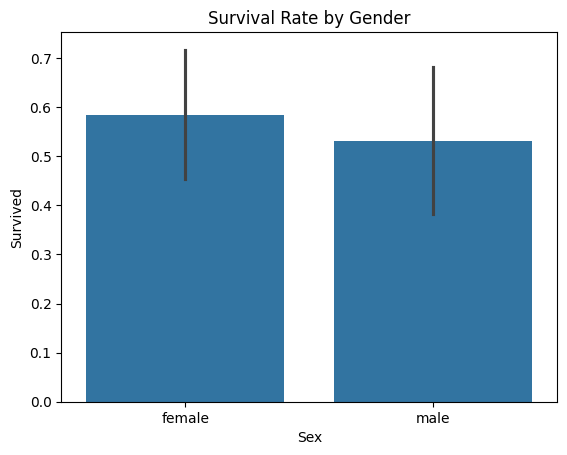

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

titanic = pd.read_csv("titanic.csv")

# Group by Sex
survival_by_sex = titanic.groupby('Sex')['Survived'].mean()
print(survival_by_sex)

# Plot
sns.barplot(x='Sex', y='Survived', data=titanic)
plt.title("Survival Rate by Gender")
plt.show()


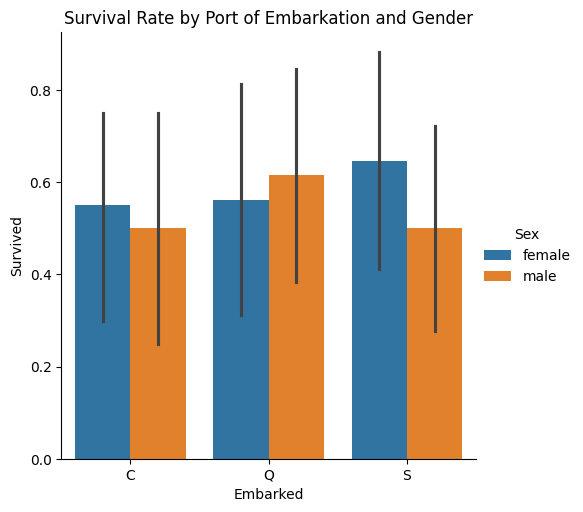

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(x="Embarked", y="Survived", hue="Sex",
            data=titanic, kind="bar")

plt.title("Survival Rate by Port of Embarkation and Gender")
plt.show()


/tmp/ipython-input-2322862450.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_table = titanic.groupby(['Pclass','AgeGroup'])['Survived'].mean()


Pclass  AgeGroup        
1       (-0.001, 17.952]    0.666667
        (17.952, 26.134]    0.888889
        (26.134, 32.348]    0.500000
        (32.348, 40.513]    0.166667
        (40.513, 72.855]    0.714286
2       (-0.001, 17.952]    0.428571
        (17.952, 26.134]    0.500000
        (26.134, 32.348]    0.666667
        (32.348, 40.513]    0.333333
        (40.513, 72.855]    0.333333
3       (-0.001, 17.952]    0.500000
        (17.952, 26.134]    0.857143
        (26.134, 32.348]    0.500000
        (32.348, 40.513]    0.636364
        (40.513, 72.855]    0.285714
Name: Survived, dtype: float64


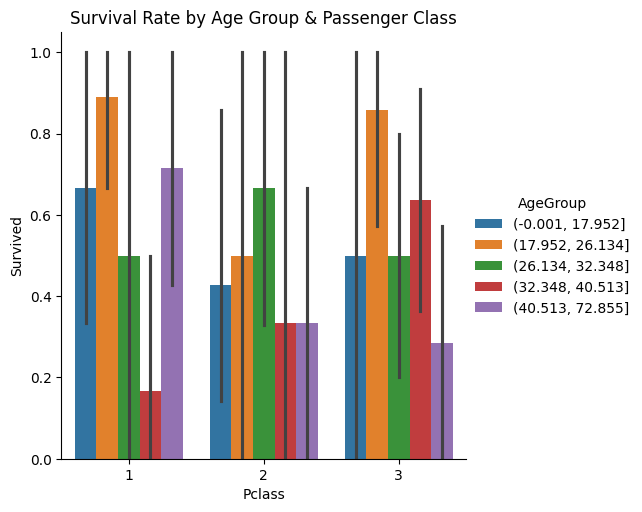

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

titanic = pd.read_csv("titanic.csv")

# Create 5 age quantile groups
titanic['AgeGroup'] = pd.qcut(titanic['Age'], 5)

# Calculate mean survival by AgeGroup and Pclass
survival_table = titanic.groupby(['Pclass','AgeGroup'])['Survived'].mean()
print(survival_table)

# Plot
sns.catplot(x='Pclass', y='Survived', hue='AgeGroup',
            data=titanic, kind='bar')
plt.title("Survival Rate by Age Group & Passenger Class")
plt.show()


In [ ]:
import pandas as pd

print(pd.read_csv("bank.csv").head())
print(pd.read_csv("medical_student.csv").head())
print(pd.read_csv("titanic.csv").head())


In [ ]:
import os
os.listdir()


In [ ]:
os.listdir()
